<a href="https://colab.research.google.com/github/farrelrassya/ML-DS-blueprints-for-finance/blob/main/Chapter_03_neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3 — Artificial Neural Networks

This notebook accompanies Chapter 3 of *Machine Learning and Data Science Blueprints for Finance*. We build a complete conceptual foundation for **Artificial Neural Networks (ANNs)**: their architecture, the training procedure (forward propagation, backpropagation, gradient descent), the full set of hyperparameters that govern model behavior, and a worked Keras implementation.

ANNs are the computational substrate of modern deep learning. They underlie virtually every state-of-the-art system in computer vision, natural language processing, reinforcement learning, and increasingly, quantitative finance. Understanding them at both the mathematical and engineering levels is non-negotiable for any practitioner.

We will cover:

1. **Architecture** — neurons, layers (input, hidden, output), and weights
2. **Training** — forward propagation, the loss function, gradient descent, and backpropagation
3. **Hyperparameters** — depth, width, learning rate, activation functions, cost functions, optimizers, epochs, and batch size
4. **Implementation** — building, compiling, fitting, and evaluating an ANN in Keras
5. **Acceleration** — using GPUs and cloud services for large models

The chapter is deliberately framework-light. The Keras example at the end is a minimal demonstration; the case studies in subsequent chapters will apply these concepts to real financial problems.

## 0. Setup

We install and import the libraries used throughout the notebook. The mathematical demonstrations (single neuron, activation functions, gradient descent, optimizers) run on NumPy and Matplotlib alone. The final implementation section uses **Keras** (now distributed as part of TensorFlow); those cells are marked and produce outputs when run on Google Colab.

In [1]:
# Install packages (Colab already has most of these; tensorflow is large and pre-installed on Colab)
# !pip install -q tensorflow

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

np.random.seed(42)
print(f"NumPy version:      {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

NumPy version:      2.0.2
Matplotlib version: 3.10.0


We fix the random seed to $42$ so every stochastic computation in the notebook is reproducible. **Reproducibility is a non-negotiable engineering requirement** when comparing model variants — without a fixed seed, you cannot tell whether a change in accuracy came from your hyperparameter tweak or from the random initialization of weights.

## 1. What Is an Artificial Neural Network?

An **Artificial Neural Network (ANN)** is a computing system inspired — loosely — by the biological neural networks that constitute animal brains. It consists of connected units called **artificial neurons** (or **nodes**, or **perceptrons**) organized into **layers**. Each connection transmits a signal from one neuron to another, much like a synapse in a biological brain.

The defining feature of an ANN is its capacity to **learn**: by adjusting the strength (the *weight*) of each connection, the network discovers patterns in data without being explicitly programmed with rules. The phrase **deep learning** refers to the study of ANNs with many layers, where information flows through elaborate nested transformations. Deep networks represent the world as a **hierarchy of concepts**: each successive layer combines simpler features from the previous layer into more abstract ones. A face-recognition network, for instance, might learn edges in its first layer, eyes and noses in its third, and identities in its tenth.

ANNs are not a single algorithm but a *family* of models that span every category of machine learning — supervised, unsupervised, and reinforcement learning. This generality is why we dedicate an entire chapter to them before tackling the supervised-learning case studies in later chapters.

## 2. Architecture of ANNs

An ANN architecture has three ingredients: **neurons**, **layers**, and **weights**. We address each in turn.

### 2.1 The Neuron — The Atomic Unit

The neuron is the basic computational unit of an ANN. It takes one or more inputs $x_1, x_2, \ldots, x_n$, computes a **weighted sum** plus a bias, and passes that sum through a nonlinear **activation function** $f$ to produce its output:

$$z = \sum_{i=1}^{n} w_i x_i + b = \mathbf{w}^{\top} \mathbf{x} + b, \qquad \text{output} = f(z)$$

Symbol by symbol:

- $\mathbf{x} \in \mathbb{R}^n$ is the input vector — the features the neuron sees.
- $\mathbf{w} \in \mathbb{R}^n$ is the **weight vector** — the parameters the neuron *learns*. Each $w_i$ measures how strongly input $i$ influences this neuron.
- $b \in \mathbb{R}$ is the **bias** — a learnable offset that lets the neuron shift its activation threshold independently of the inputs.
- $z$ is the **pre-activation** (or **logit**) — the raw linear combination.
- $f$ is the **activation function** — a nonlinear transformation that gives the network its representational power. Without $f$, a stack of neurons would collapse to a single linear map.

![Figure 3-1: An artificial neuron](figures/figure_3_1.png)

**Figure 3-1.** *An artificial neuron.* The neuron receives inputs $x_1, x_2, \ldots, x_n$, multiplies each by a learnable weight $w_1, w_2, \ldots, w_n$, sums the products (together with a bias $b$) to form the pre-activation $z$, and passes $z$ through the activation function $f$ to produce the neuron's output $f(z)$. The weights $\mathbf{w}$ and bias $b$ are what the training algorithm adjusts.

Let us compute the output of a single neuron concretely. We will use four inputs, fix the weights and bias, and apply three different activation functions to the same pre-activation $z$.

In [2]:
# A single neuron with 4 inputs
x = np.array([0.5, -0.3, 0.8, 0.2])     # input vector
w = np.array([0.4, -0.6, 0.9, 0.1])     # learnable weights
b = 0.1                                  # learnable bias

# Pre-activation: weighted sum + bias
z = np.dot(w, x) + b
print(f"Inputs   x = {x}")
print(f"Weights  w = {w}")
print(f"Bias     b = {b}")
print(f"")
print(f"Pre-activation z = w . x + b = {z:.4f}")
print(f"")
print(f"Activation outputs for this z:")
print(f"  Linear  f(z) = z              = {z:.4f}")
print(f"  Sigmoid f(z) = 1/(1+exp(-z))  = {1/(1+np.exp(-z)):.4f}")
print(f"  Tanh    f(z) = tanh(z)        = {np.tanh(z):.4f}")
print(f"  ReLU    f(z) = max(0, z)      = {max(0, z):.4f}")

Inputs   x = [ 0.5 -0.3  0.8  0.2]
Weights  w = [ 0.4 -0.6  0.9  0.1]
Bias     b = 0.1

Pre-activation z = w . x + b = 1.2200

Activation outputs for this z:
  Linear  f(z) = z              = 1.2200
  Sigmoid f(z) = 1/(1+exp(-z))  = 0.7721
  Tanh    f(z) = tanh(z)        = 0.8397
  ReLU    f(z) = max(0, z)      = 1.2200


The pre-activation works out to $z = (0.4)(0.5) + (-0.6)(-0.3) + (0.9)(0.8) + (0.1)(0.2) + 0.1 = \mathbf{1.2200}$. Plugging this single number into four different activations produces four different outputs:

- **Linear:** $f(z) = 1.2200$. No nonlinearity, output equals the input. Useless on its own as a building block — a stack of linear neurons is mathematically equivalent to *one* linear neuron.
- **Sigmoid:** $f(z) = 1/(1 + e^{-1.22}) = \mathbf{0.7721}$. Compresses the real line into $(0, 1)$. The value $0.77$ can be interpreted as a probability.
- **Tanh:** $f(z) = \tanh(1.22) = \mathbf{0.8397}$. Same S-shape as sigmoid, but compresses into $(-1, 1)$. Zero-centered output is often easier for downstream layers to learn from.
- **ReLU:** $f(z) = \max(0, 1.22) = \mathbf{1.2200}$. Since $z$ is positive, ReLU passes it through unchanged. For any negative $z$, ReLU outputs exactly $0$.

**Why this matters in production.** A single neuron is a *generalized linear model*. With sigmoid activation it is logistic regression. With linear activation it is ordinary linear regression. The leap from machine learning to *deep* learning is what happens when we stack thousands of these units in layers — the resulting composition can approximate arbitrarily complex functions (the **universal approximation theorem**).

### 2.2 Layers — Stacking Neurons

A single neuron's expressive power is limited; it can only carve the input space with a single hyperplane (followed by a nonlinearity). To model complex relationships we stack neurons in **layers**, and stack layers in sequence.

Three types of layer appear in every feed-forward network:

- **Input layer** — exposed to the data. One neuron per input feature. These neurons perform no computation; they simply pass values through.
- **Hidden layers** — between input and output. These do the actual work of feature transformation. A network with more than three hidden layers is conventionally called a **deep neural network**.
- **Output layer** — produces the final prediction. Its shape and activation are dictated by the task: one sigmoid neuron for binary classification, $K$ softmax neurons for $K$-class classification, one linear neuron for scalar regression.

The power of multi-layer networks comes from **feature hierarchy**: each hidden layer learns to recombine the features from the previous layer into more abstract ones. In a network trained on images, early hidden layers learn edges and corners, middle layers learn motifs and textures, and deep layers learn whole objects.

![Figure 3-2: Neural network architecture](figures/figure_3_2.png)

**Figure 3-2.** *Neural network architecture.* A simple feed-forward ANN with an input layer (left), a single hidden layer (middle), and an output layer (right). Every neuron in one layer is connected to every neuron in the next — this is a **fully connected** (or **dense**) network. Each edge in the diagram corresponds to one learnable weight $w_{ij}$.

### 2.3 Neuron Weights — What the Network Learns

A **neuron weight** $w_{ij}$ measures the strength of the connection from neuron $i$ to neuron $j$. The collection of all weights (plus biases) constitutes the network's **parameters** $\mathbf{w}$ — these are what training adjusts.

The sign and magnitude of a weight have a direct interpretation:

| Weight value | Meaning |
|---|---|
| Large positive $w_{ij}$ | Increasing input $i$ strongly *increases* the activation of neuron $j$ |
| Large negative $w_{ij}$ | Increasing input $i$ strongly *decreases* the activation of neuron $j$ |
| $w_{ij} \approx 0$ | Input $i$ has essentially no influence on neuron $j$ |

For a fully connected network with layer sizes $n_0 \to n_1 \to n_2 \to \cdots \to n_L$, the total number of parameters is:

$$\text{params} = \sum_{\ell=1}^{L} \big(n_{\ell-1} \cdot n_{\ell} + n_{\ell}\big) = \underbrace{\sum_{\ell} n_{\ell-1} n_{\ell}}_{\text{weights}} + \underbrace{\sum_{\ell} n_{\ell}}_{\text{biases}}$$

Let us count parameters for the small network we will build later: $10 \to 32 \to 32 \to 1$.

In [3]:
# Parameter count for a 10 -> 32 -> 32 -> 1 network
layer_sizes = [10, 32, 32, 1]

total_weights = 0
total_biases  = 0
for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:]):
    w = n_in * n_out
    b = n_out
    total_weights += w
    total_biases  += b
    print(f"Layer {n_in:>3} -> {n_out:<3}:  {w:>4} weights + {b:>3} biases = {w+b:>4} params")

print("-" * 50)
print(f"Total weights: {total_weights}")
print(f"Total biases:  {total_biases}")
print(f"Total params:  {total_weights + total_biases}")

Layer  10 -> 32 :   320 weights +  32 biases =  352 params
Layer  32 -> 32 :  1024 weights +  32 biases = 1056 params
Layer  32 -> 1  :    32 weights +   1 biases =   33 params
--------------------------------------------------
Total weights: 1376
Total biases:  65
Total params:  1441


The network has **1,441 parameters** — split as $1{,}376$ weights and $65$ biases. Per-layer:

- Input $\to$ Hidden 1 ($10 \to 32$): $10 \times 32 + 32 = 320 + 32 = 352$ params
- Hidden 1 $\to$ Hidden 2 ($32 \to 32$): $32 \times 32 + 32 = 1{,}024 + 32 = 1{,}056$ params  
- Hidden 2 $\to$ Output ($32 \to 1$): $32 \times 1 + 1 = 32 + 1 = 33$ params

**Strategic insight.** Parameter count scales as $O(n_{\ell-1} \cdot n_{\ell})$, so the middle layers of a deep network dominate the parameter budget. A network with hidden width $h$ and depth $L$ has roughly $L \cdot h^2$ parameters — doubling the width quadruples the memory cost. In production this dictates everything: training time, GPU memory, inference latency, and the volume of training data required to avoid overfitting. The rough rule of thumb that the number of training examples should exceed the number of parameters by an order of magnitude is a direct consequence of this scaling.

## 3. Training an ANN

Training an ANN means **calibrating the weights** $\mathbf{w}$ so that the network's predictions match the desired outputs on the training data. The procedure is iterative and alternates two passes through the network:

1. **Forward propagation** — push inputs through the network and produce a prediction.
2. **Backpropagation** — compute how each weight contributed to the prediction error and update it.

### 3.1 Forward Propagation

Forward propagation feeds an input $\mathbf{x}$ into the first layer and computes activations layer by layer until the output. For a network with $L$ layers, weight matrices $\mathbf{W}^{(\ell)}$, bias vectors $\mathbf{b}^{(\ell)}$, and activation function $f$:

$$\mathbf{a}^{(0)} = \mathbf{x}$$
$$\mathbf{z}^{(\ell)} = \mathbf{W}^{(\ell)} \mathbf{a}^{(\ell-1)} + \mathbf{b}^{(\ell)}, \quad \mathbf{a}^{(\ell)} = f\big(\mathbf{z}^{(\ell)}\big), \quad \ell = 1, \ldots, L$$
$$\hat{\mathbf{y}} = \mathbf{a}^{(L)}$$

Each $\mathbf{a}^{(\ell)}$ is the **activation** of layer $\ell$ — the vector of outputs of that layer's neurons. The final activation $\hat{\mathbf{y}}$ is the network's prediction.

Let us implement one full forward pass for a tiny network $4 \to 3 \to 2 \to 1$ to make the equations concrete.

In [4]:
# Forward propagation through a 4 -> 3 -> 2 -> 1 network
np.random.seed(0)

# Input
x = np.array([1.0, 0.5, -0.5, 1.5])
print(f"Input a^(0) = {x}, shape {x.shape}")

# Layer 1: 4 -> 3 (with ReLU)
W1 = np.random.randn(3, 4) * 0.5
b1 = np.zeros(3)
z1 = W1 @ x + b1
a1 = np.maximum(0, z1)          # ReLU
print(f"\nLayer 1 (4 -> 3, ReLU):")
print(f"  W1 shape: {W1.shape}, b1 shape: {b1.shape}")
print(f"  z^(1) = {z1.round(4)}")
print(f"  a^(1) = {a1.round(4)}")

# Layer 2: 3 -> 2 (with ReLU)
W2 = np.random.randn(2, 3) * 0.5
b2 = np.zeros(2)
z2 = W2 @ a1 + b2
a2 = np.maximum(0, z2)
print(f"\nLayer 2 (3 -> 2, ReLU):")
print(f"  W2 shape: {W2.shape}, b2 shape: {b2.shape}")
print(f"  z^(2) = {z2.round(4)}")
print(f"  a^(2) = {a2.round(4)}")

# Layer 3: 2 -> 1 (with sigmoid)
W3 = np.random.randn(1, 2) * 0.5
b3 = np.zeros(1)
z3 = W3 @ a2 + b3
y_hat = 1 / (1 + np.exp(-z3))   # sigmoid
print(f"\nLayer 3 (2 -> 1, sigmoid):")
print(f"  W3 shape: {W3.shape}, b3 shape: {b3.shape}")
print(f"  z^(3) = {z3.round(4)}")
print(f"  y_hat = {y_hat.round(4)}")

Input a^(0) = [ 1.   0.5 -0.5  1.5], shape (4,)

Layer 1 (4 -> 3, ReLU):
  W1 shape: (3, 4), b1 shape: (3,)
  z^(1) = [2.4181 0.3384 1.1057]
  a^(1) = [2.4181 0.3384 1.1057]

Layer 2 (3 -> 2, ReLU):
  W2 shape: (2, 3), b2 shape: (2,)
  z^(2) = [1.1861 0.5428]
  a^(2) = [1.1861 0.5428]

Layer 3 (2 -> 1, sigmoid):
  W3 shape: (1, 2), b3 shape: (1,)
  z^(3) = [-0.0461]
  y_hat = [0.4885]


The input $\mathbf{x} = [1.0, 0.5, -0.5, 1.5]$ propagates through three layers. With this random seed all pre-activations happened to come out positive, so ReLU passed every value through unchanged ($\mathbf{a}^{(\ell)} = \mathbf{z}^{(\ell)}$). On a different seed some components would have been zeroed; that is ReLU's defining behavior.

1. **Layer 1** transforms the 4-dim input into a 3-dimensional pre-activation $\mathbf{z}^{(1)} = [2.4181, 0.3384, 1.1057]$, all positive, so $\mathbf{a}^{(1)} = \mathbf{z}^{(1)}$.
2. **Layer 2** further transforms it into a 2-dimensional vector $\mathbf{a}^{(2)} = [1.1861, 0.5428]$.
3. **Layer 3** collapses it to a single sigmoid-squashed value $\hat{y} = 0.4885$ between $0$ and $1$ — a binary-classification probability essentially at the decision boundary.

Notice the **matrix shapes** stack consistently:
$$\underbrace{(3, 4)}_{\mathbf{W}^{(1)}} \cdot \underbrace{(4,)}_{\mathbf{x}} \;\to\; \underbrace{(3,)}_{\mathbf{a}^{(1)}}; \quad \underbrace{(2, 3)}_{\mathbf{W}^{(2)}} \cdot \underbrace{(3,)}_{\mathbf{a}^{(1)}} \;\to\; \underbrace{(2,)}_{\mathbf{a}^{(2)}}; \quad \underbrace{(1, 2)}_{\mathbf{W}^{(3)}} \cdot \underbrace{(2,)}_{\mathbf{a}^{(2)}} \;\to\; \underbrace{(1,)}_{\hat{y}}.$$

Every forward pass is a chain of matrix-vector multiplies and elementwise nonlinearities. On a GPU these operations parallelize trivially across thousands of cores, which is exactly why deep learning lives on GPUs rather than CPUs.

### 3.2 Backpropagation and Gradient Descent

Forward propagation gives us a prediction $\hat{\mathbf{y}}$. To train, we need a way to *change* the weights so the prediction moves closer to the desired output $\mathbf{y}$. This requires two ingredients:

**(a) A loss function $J(\mathbf{w})$** that quantifies the gap between $\hat{\mathbf{y}}$ and $\mathbf{y}$. For example, the squared error $J(\mathbf{w}) = \tfrac{1}{2}\|\mathbf{y} - \hat{\mathbf{y}}\|^2$, which is itself a function of $\mathbf{w}$ because $\hat{\mathbf{y}}$ depends on the weights.

**(b) Gradient descent** — an algorithm that moves $\mathbf{w}$ in the direction that most rapidly decreases $J$:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \, \nabla_{\mathbf{w}} J(\mathbf{w})$$

where $\eta > 0$ is the **learning rate** and $\nabla_{\mathbf{w}} J$ is the gradient (vector of partial derivatives) of the loss with respect to each weight. **Intuition:** the gradient points in the direction of *steepest increase* of $J$; we step in the *opposite* direction to descend.

![Figure 3-3: Gradient descent](figures/figure_3_3.png)

**Figure 3-3.** *Gradient descent.* A schematic of the loss surface $J(w)$ as a function of a single weight $w$. The algorithm starts at some initial point, computes the local slope $\nabla J(w)$, and takes a small step in the direction of the negative gradient. Repeated iteration drives $w$ toward a minimum of $J$.

**Backpropagation** is the algorithm that computes $\nabla_{\mathbf{w}} J$ efficiently. The loss is a *composition* of layer functions — if layer 1 is $p(\cdot)$, layer 2 is $q(\cdot)$, and layer 3 is $r(\cdot)$, then $J(\mathbf{w}) = r(q(p(\mathbf{x}; \mathbf{w}_1); \mathbf{w}_2); \mathbf{w}_3)$. By the **chain rule**, the gradient with respect to a weight in layer 1 is a product of gradients flowing back from layer 3 through layer 2:

$$\frac{\partial J}{\partial \mathbf{w}_1} = \underbrace{\frac{\partial J}{\partial r}}_{\text{from layer 3}} \cdot \underbrace{\frac{\partial r}{\partial q}}_{\text{through layer 2}} \cdot \underbrace{\frac{\partial q}{\partial p}}_{\text{through layer 1}} \cdot \frac{\partial p}{\partial \mathbf{w}_1}$$

Computing these gradients **layer-by-layer in reverse order** — starting at the loss and moving backward toward the input — is what gives backpropagation its name. It is the most efficient general procedure for computing gradients in a deep network: the cost of a backward pass is approximately the same as a forward pass, regardless of network depth. This is why training a 100-layer network is computationally tractable at all.

Let us visualize gradient descent on a one-dimensional loss surface.

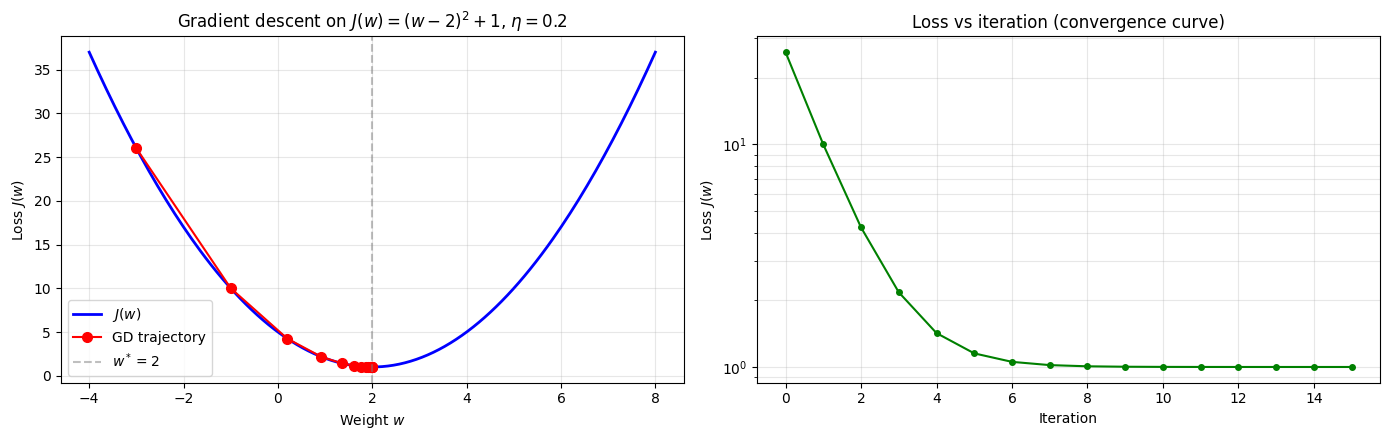

Initial weight: w_0 = -3.0000, J = 26.0000
Final weight:   w_15 = 1.9976, J = 1.000006
True minimum:   w* = 2.0,         J = 1.0


In [5]:
# Gradient descent on J(w) = (w - 2)^2 + 1, minimum at w* = 2
def J(w):    return (w - 2)**2 + 1
def dJ(w):   return 2 * (w - 2)

w_grid = np.linspace(-4, 8, 200)

# Run gradient descent
lr = 0.2
w = -3.0
trajectory = [w]
losses = [J(w)]
for step in range(15):
    w = w - lr * dJ(w)
    trajectory.append(w)
    losses.append(J(w))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(w_grid, J(w_grid), 'b-', linewidth=2, label='$J(w)$')
axes[0].plot(trajectory, [J(w) for w in trajectory], 'ro-', markersize=7, linewidth=1.5, label='GD trajectory')
axes[0].axvline(2, color='gray', linestyle='--', alpha=0.5, label='$w^* = 2$')
axes[0].set_xlabel('Weight $w$')
axes[0].set_ylabel('Loss $J(w)$')
axes[0].set_title(f'Gradient descent on $J(w)=(w-2)^2+1$, $\eta={lr}$')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(range(len(losses)), losses, 'g.-', markersize=8, linewidth=1.5)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss $J(w)$')
axes[1].set_title('Loss vs iteration (convergence curve)')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('gradient_descent.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Initial weight: w_0 = {trajectory[0]:.4f}, J = {losses[0]:.4f}")
print(f"Final weight:   w_{len(trajectory)-1} = {trajectory[-1]:.4f}, J = {losses[-1]:.6f}")
print(f"True minimum:   w* = 2.0,         J = 1.0")

Starting from $w_0 = -3.0$ where the loss is $J(-3) = 26.0$, gradient descent with learning rate $\eta = 0.2$ converges in 15 iterations to $w_{15} \approx 1.9976$, essentially the true minimum $w^{*} = 2.0$. The loss drops from $26.0$ to $1.000006$ — the residual above $1.0$ comes from the irreducible minimum $J(2) = 1$ since $J(w) = (w-2)^2 + 1 \geq 1$.

**The update rule in action.** At $w_0 = -3$, the gradient is $\nabla J(-3) = 2(-3 - 2) = -10$, so the update is:
$$w_1 = -3 - (0.2)(-10) = -3 + 2 = -1$$
The first step moves us **2 units** in weight space (from $-3$ to $-1$), much faster than the later steps. As the optimizer approaches the minimum, the gradient magnitude shrinks proportionally to the distance from $w^{*}$, so the steps become smaller and smaller — visible in the right-hand plot as the log-scale loss decays linearly (geometric convergence).

**Strategic insights.**

- **Learning rate matters enormously.** Too small ($\eta = 0.001$) and the trajectory crawls. Too large ($\eta = 1.5$) and the iterates *overshoot* the minimum and diverge.
- **The loss surface here is convex** (a parabola), so gradient descent is guaranteed to reach the global minimum. In a real ANN, the loss surface is wildly non-convex with many local minima, saddle points, and plateaus — yet empirically, gradient descent with momentum-based optimizers still finds *good* solutions. Why this works is an active area of research.
- **Backpropagation is what makes this practical.** Computing $\nabla J$ for a network with 100 million parameters by hand is impossible; by the chain rule it is automatic.

## 4. Hyperparameters

**Hyperparameters** are settings fixed before training that govern the model's structure and the optimization procedure. They cannot be learned from data — they must be chosen by the practitioner (often by trial, grid search, or Bayesian optimization). The high count of hyperparameters in ANNs is both their greatest strength (flexibility) and their greatest practical headache (tuning effort).

We cover the most important ones below.

### 4.1 Number of Hidden Layers and Nodes

More layers and wider layers mean more parameters, which means greater capacity to fit complex functions — but also greater risk of overfitting and longer training times. There is no universal formula, but the following heuristics are useful starting points:

**Depth (number of hidden layers).**

- For most tabular problems: start with 1–2 hidden layers, increase only if you see clear underfitting.
- For image classification at modern scale: tens to hundreds of layers (ResNet-152, EfficientNet, etc.).
- For language models: dozens to hundreds of transformer layers.

**Width (nodes per hidden layer).**

- A common rule of thumb: the width of each hidden layer should lie between the input size $n_{\text{in}}$ and the output size $n_{\text{out}}$, often around the geometric or arithmetic mean.
- A stricter rule to limit overfitting: $n_{\text{hidden}} \leq 2 n_{\text{in}}$.

The capacity of a network grows roughly as $L \cdot h^2$ where $L$ is depth and $h$ is width. **Doubling the width quadruples the parameter count.**

### 4.2 Activation Functions

The activation function $f$ is the source of an ANN's nonlinearity. Without it, the composition of any number of layers reduces to a single linear map — no representational power beyond linear regression. With it, even a single hidden layer can approximate any continuous function (universal approximation theorem).

The four most common activations are:

| Function | Formula | Range | Derivative | Notes |
|---|---|---|---|---|
| **Linear** | $f(z) = z$ | $(-\infty, \infty)$ | $1$ | Useful only in the output layer for regression |
| **Sigmoid** | $f(z) = \dfrac{1}{1+e^{-z}}$ | $(0, 1)$ | $f(z)\,(1-f(z))$ | Probabilistic output; saturates and kills gradients |
| **Tanh** | $f(z) = \dfrac{e^z - e^{-z}}{e^z + e^{-z}}$ | $(-1, 1)$ | $1 - f(z)^2$ | Zero-centered; still saturates |
| **ReLU** | $f(z) = \max(0, z)$ | $[0, \infty)$ | $\mathbf{1}_{z>0}$ | Default choice; cheap, no saturation on positive side |

Let us visualize all four together with their derivatives.

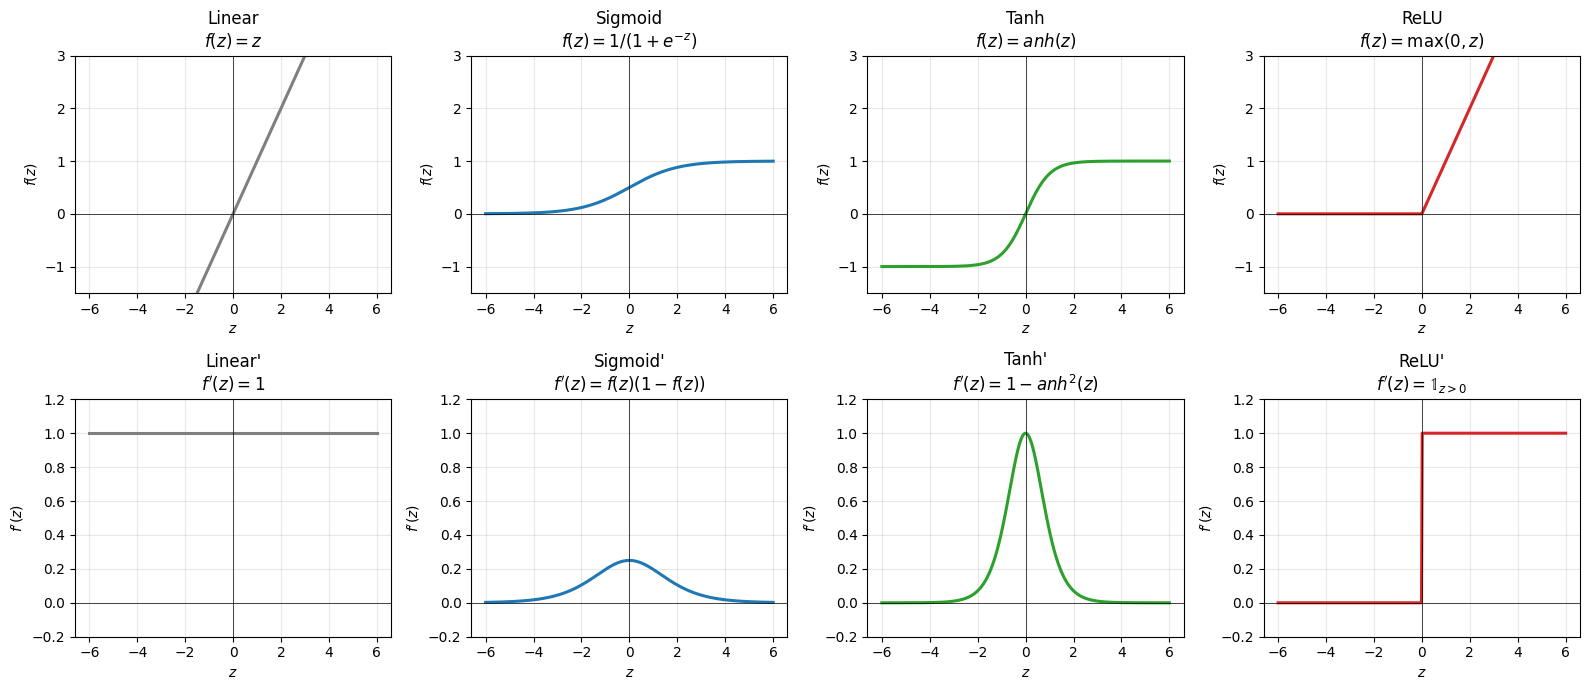

Max derivative of sigmoid: 0.2500  (at z=0)
Max derivative of tanh:    0.9998  (at z=0)
Derivative of ReLU:        1.0 for z>0, 0 for z<0


In [6]:
# Visualize activation functions and their derivatives
z = np.linspace(-6, 6, 400)

linear      = z
sigmoid     = 1 / (1 + np.exp(-z))
tanh        = np.tanh(z)
relu        = np.maximum(0, z)

dlinear     = np.ones_like(z)
dsigmoid    = sigmoid * (1 - sigmoid)
dtanh       = 1 - tanh**2
drelu       = (z > 0).astype(float)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

# Top row: activations
configs = [
    (linear,  'Linear',  '$f(z)=z$',                'tab:gray'),
    (sigmoid, 'Sigmoid', '$f(z)=1/(1+e^{-z})$',     'tab:blue'),
    (tanh,    'Tanh',    '$f(z)=\tanh(z)$',          'tab:green'),
    (relu,    'ReLU',    '$f(z)=\max(0,z)$',         'tab:red'),
]
for ax, (y, name, formula, color) in zip(axes[0], configs):
    ax.plot(z, y, color=color, linewidth=2.2)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_title(f'{name}\n{formula}')
    ax.set_xlabel('$z$')
    ax.set_ylabel('$f(z)$')
    ax.grid(alpha=0.3)
    ax.set_ylim(-1.5, 3)

# Bottom row: derivatives
dconfigs = [
    (dlinear,  "Linear'",   "$f'(z)=1$",                          'tab:gray'),
    (dsigmoid, "Sigmoid'",  "$f'(z)=f(z)(1-f(z))$",                'tab:blue'),
    (dtanh,    "Tanh'",     "$f'(z)=1-\tanh^2(z)$",                'tab:green'),
    (drelu,    "ReLU'",     "$f'(z)=\mathbb{1}_{z>0}$",            'tab:red'),
]
for ax, (y, name, formula, color) in zip(axes[1], dconfigs):
    ax.plot(z, y, color=color, linewidth=2.2)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_title(f'{name}\n{formula}')
    ax.set_xlabel('$z$')
    ax.set_ylabel("$f'(z)$")
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.2, 1.2)

plt.tight_layout()
plt.savefig('activation_functions.png', dpi=100, bbox_inches='tight')
plt.show()

# Print maximum derivatives — relevant to vanishing gradients
print(f"Max derivative of sigmoid: {dsigmoid.max():.4f}  (at z=0)")
print(f"Max derivative of tanh:    {dtanh.max():.4f}  (at z=0)")
print(f"Derivative of ReLU:        1.0 for z>0, 0 for z<0")

![Figure 3-4: Activation functions and their derivatives](figures/figure_3_4.png)

**Figure 3-4.** *Activation functions and their derivatives.* Top row: the four functions themselves. Bottom row: their derivatives, which are what gets multiplied through the chain rule during backpropagation.

**Reading the bottom row is more important than reading the top row.** During backpropagation, the gradient flowing backward through a layer is multiplied by $f'(z)$. The shape of $f'$ therefore controls how well the gradient signal *survives* the trip from the output back to early layers.

- **Sigmoid's derivative peaks at $0.25$** (when $z = 0$) and falls to nearly $0$ for $|z| > 4$. Stack ten sigmoid layers and a unit gradient at the output becomes at most $0.25^{10} \approx 9.5 \times 10^{-7}$ at the input. This is the classical **vanishing gradient problem** that crippled deep networks before 2010.
- **Tanh's derivative peaks at $1.0$** (when $z = 0$), better than sigmoid, but still saturates for $|z|$ large.
- **ReLU's derivative is exactly $1$ wherever $z > 0$** — the gradient passes through undamped. This single fact, together with its trivial computational cost, is why ReLU and its variants (Leaky ReLU, GELU, Swish) dominate modern deep networks. The cost is **dead neurons**: if a ReLU neuron's pre-activation is always negative, its gradient is always zero and it stops learning.

**Practical guidance:**

- Hidden layers: use **ReLU** by default. Switch to Leaky ReLU or GELU if you suspect dead neurons.
- Output layer: dictated by the task. Use **sigmoid** for binary classification, **softmax** for multi-class classification, **linear** for regression.

### 4.3 Cost (Loss) Functions

The **cost function** $J(\mathbf{w})$ measures how well the network's predictions $\hat{\mathbf{y}}$ match the targets $\mathbf{y}$. It is the objective that gradient descent minimizes. The choice of loss is dictated by the task type:

**Mean Squared Error (MSE)** — for regression:

$$J_{\text{MSE}}(\mathbf{w}) = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

MSE penalizes large errors quadratically; a prediction off by $2$ costs four times as much as one off by $1$. This makes it sensitive to outliers — sometimes a feature (you really care about big errors) and sometimes a bug (a single outlier dominates training).

**Cross-Entropy (Log Loss)** — for classification:

$$J_{\text{CE}}(\mathbf{w}) = -\frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{C} y_{i,c} \log(\hat{y}_{i,c})$$

where $y_{i,c} \in \{0, 1\}$ is the one-hot label and $\hat{y}_{i,c}$ is the predicted probability for class $c$. For binary classification this simplifies to:

$$J_{\text{BCE}}(\mathbf{w}) = -\frac{1}{N} \sum_{i=1}^{N} \big[\, y_i \log \hat{y}_i + (1 - y_i) \log(1 - \hat{y}_i) \,\big]$$

A perfect classifier — predicting the correct class with probability $1$ for every example — has cross-entropy of exactly $0$.

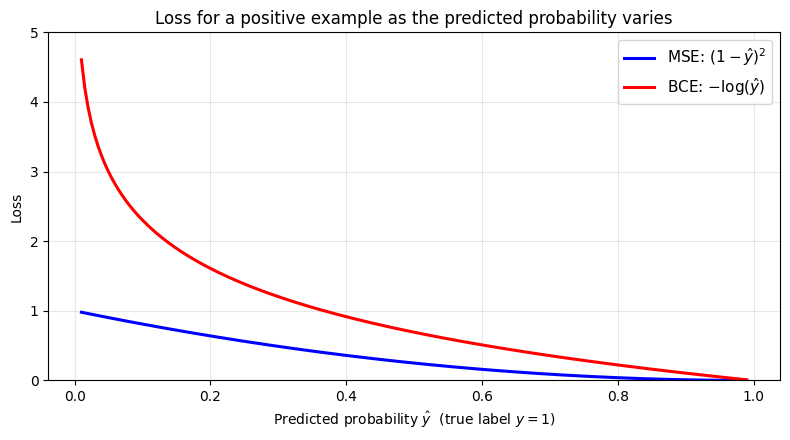

For y=1, y_hat=0.01:  MSE = 0.9801,  BCE = 4.6052
For y=1, y_hat=0.10:  MSE = 0.8100,  BCE = 2.3026
For y=1, y_hat=0.50:  MSE = 0.2500,  BCE = 0.6931
For y=1, y_hat=0.90:  MSE = 0.0100,  BCE = 0.1054
For y=1, y_hat=0.99:  MSE = 0.0001,  BCE = 0.0101


In [7]:
# Compare MSE and binary cross-entropy losses for a single example
# True label y=1, vary the predicted probability y_hat from 0.01 to 0.99
y_hat = np.linspace(0.01, 0.99, 200)

# MSE (treating y=1 as a regression target)
mse_y1 = (1 - y_hat)**2
# Binary cross-entropy
bce_y1 = -np.log(y_hat)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(y_hat, mse_y1, 'b-',  linewidth=2.2, label='MSE: $(1 - \hat{y})^2$')
ax.plot(y_hat, bce_y1, 'r-',  linewidth=2.2, label='BCE: $-\log(\hat{y})$')
ax.set_xlabel('Predicted probability $\hat{y}$  (true label $y = 1$)')
ax.set_ylabel('Loss')
ax.set_title('Loss for a positive example as the predicted probability varies')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0, 5)
plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"For y=1, y_hat=0.01:  MSE = {(1-0.01)**2:.4f},  BCE = {-np.log(0.01):.4f}")
print(f"For y=1, y_hat=0.10:  MSE = {(1-0.10)**2:.4f},  BCE = {-np.log(0.10):.4f}")
print(f"For y=1, y_hat=0.50:  MSE = {(1-0.50)**2:.4f},  BCE = {-np.log(0.50):.4f}")
print(f"For y=1, y_hat=0.90:  MSE = {(1-0.90)**2:.4f},  BCE = {-np.log(0.90):.4f}")
print(f"For y=1, y_hat=0.99:  MSE = {(1-0.99)**2:.4f},  BCE = {-np.log(0.99):.4f}")

The comparison reveals why cross-entropy is the standard for classification:

| Predicted $\hat{y}$ | MSE loss | BCE loss |
|---:|---:|---:|
| $0.01$ | $0.9801$ | $4.6052$ |
| $0.10$ | $0.8100$ | $2.3026$ |
| $0.50$ | $0.2500$ | $0.6931$ |
| $0.90$ | $0.0100$ | $0.1054$ |
| $0.99$ | $0.0001$ | $0.0101$ |

When the true label is $y = 1$ and the model is *very wrong* ($\hat{y} = 0.01$), **MSE gives a loss of $0.98$** — bounded above by $1.0$. **Cross-entropy gives a loss of $4.61$ — and grows without bound** as $\hat{y} \to 0$.

The unbounded penalty on confident wrong predictions is exactly what we want during classification training: it forces the optimizer to fix egregious errors first. MSE, by contrast, gives diminishing gradient signal as the prediction nears $0$ or $1$ — a property that, combined with sigmoid saturation in the output, can stall training entirely.

**The rule.** Use MSE for regression. Use cross-entropy for classification. Almost without exception.

### 4.4 Optimizers

The optimizer is the algorithm that applies the gradient to update the weights. Vanilla gradient descent uses the rule $\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla J$, but in practice several refinements deliver dramatically faster and more reliable convergence.

**Stochastic Gradient Descent (SGD).** Compute the gradient on a small *batch* of examples rather than the full training set. Noisy but cheap; the noise even helps escape shallow local minima.

**Momentum.** Accumulate an exponentially-weighted moving average of past gradients:

$$\mathbf{v}_t = \beta \mathbf{v}_{t-1} + (1-\beta)\nabla J(\mathbf{w}_t), \qquad \mathbf{w}_{t+1} = \mathbf{w}_t - \eta \mathbf{v}_t$$

Intuition: a ball rolling down a valley gains speed in the direction of consistent slope, and the inertia helps it traverse small bumps and plateaus.

**AdaGrad.** Adapts the learning rate **per parameter**, reducing it for parameters with large accumulated squared gradients:

$$\mathbf{w}_{t+1} = \mathbf{w}_t - \frac{\eta}{\sqrt{G_t + \varepsilon}} \nabla J(\mathbf{w}_t), \quad G_t = \sum_{\tau \leq t} \big(\nabla J(\mathbf{w}_\tau)\big)^2$$

Frequently-updated weights take smaller steps; rarely-updated weights take larger steps. The catch: $G_t$ grows monotonically, so AdaGrad's effective learning rate decays to zero — training can stall in long runs.

**RMSProp.** Fixes AdaGrad's decay problem by using an *exponentially-weighted* moving average instead of a cumulative sum:

$$G_t = \rho G_{t-1} + (1-\rho)\big(\nabla J(\mathbf{w}_t)\big)^2$$

The effective learning rate is now adaptive *and* stable across long training runs.

**Adam (Adaptive Moment Estimation).** Combines momentum and RMSProp — tracks both the first moment (mean) and second moment (uncentered variance) of gradients:

$$\mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1-\beta_1)\nabla J, \quad \mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1-\beta_2)(\nabla J)^2$$
$$\mathbf{w}_{t+1} = \mathbf{w}_t - \frac{\eta}{\sqrt{\hat{\mathbf{v}}_t} + \varepsilon} \hat{\mathbf{m}}_t$$

where $\hat{\mathbf{m}}_t, \hat{\mathbf{v}}_t$ are bias-corrected versions of $\mathbf{m}_t, \mathbf{v}_t$. Default hyperparameters $\beta_1 = 0.9, \beta_2 = 0.999, \varepsilon = 10^{-8}$ work well across an enormous range of problems. **Adam is the default optimizer for most modern deep-learning work.**

Let us race four optimizers on a single 2D loss surface to see how they differ in practice.

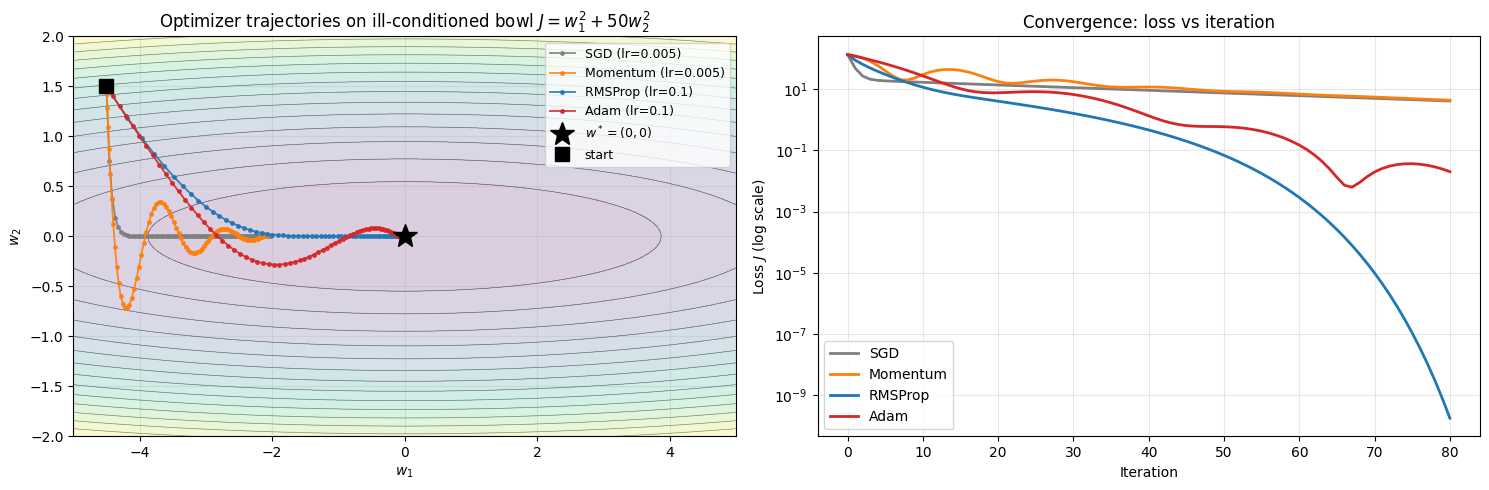

Final loss after 80 iterations (each optimizer with its tuned learning rate):
  SGD         lr=0.005   J = 4.0556e+00
  Momentum    lr=0.005   J = 4.3101e+00
  RMSProp     lr=0.1     J = 1.7876e-10
  Adam        lr=0.1     J = 1.9947e-02


In [8]:
# Race SGD, Momentum, RMSProp, and Adam on a 2D ill-conditioned bowl.
# Loss: J(w1, w2) = w1^2 + 50 * w2^2  -- condition number 50.
# We use per-optimizer learning rates tuned to each method's conventional default;
# this is the realistic scenario, since in practice you tune the LR for the optimizer.
def J_2d(w):     return w[0]**2 + 50*w[1]**2
def grad_2d(w):  return np.array([2*w[0], 100*w[1]])

def run_optimizer(name, w0, n_steps=80, lr=0.01):
    w = np.array(w0, dtype=float)
    trajectory = [w.copy()]
    v = np.zeros_like(w)
    m = np.zeros_like(w)
    G = np.zeros_like(w)
    beta1, beta2, eps = 0.9, 0.999, 1e-8
    rho = 0.9
    momentum_beta = 0.9
    for t in range(1, n_steps + 1):
        g = grad_2d(w)
        if name == 'SGD':
            w = w - lr * g
        elif name == 'Momentum':
            v = momentum_beta * v + (1 - momentum_beta) * g
            w = w - lr * v
        elif name == 'RMSProp':
            G = rho * G + (1 - rho) * g**2
            w = w - lr * g / (np.sqrt(G) + eps)
        elif name == 'Adam':
            m = beta1 * m + (1 - beta1) * g
            v = beta2 * v + (1 - beta2) * g**2
            m_hat = m / (1 - beta1**t)
            v_hat = v / (1 - beta2**t)
            w = w - lr * m_hat / (np.sqrt(v_hat) + eps)
        trajectory.append(w.copy())
    return np.array(trajectory)

w0 = [-4.5, 1.5]
n_steps = 80
# Per-optimizer learning rates tuned to each method's stable regime
optimizer_lrs = {'SGD': 0.005, 'Momentum': 0.005, 'RMSProp': 0.1, 'Adam': 0.1}
results = {opt: run_optimizer(opt, w0, n_steps=n_steps, lr=optimizer_lrs[opt])
           for opt in optimizer_lrs}

# Plot trajectories on contour
w1_grid = np.linspace(-5, 5, 200)
w2_grid = np.linspace(-2, 2, 200)
W1, W2 = np.meshgrid(w1_grid, w2_grid)
Z = W1**2 + 50*W2**2

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = {'SGD':'tab:gray', 'Momentum':'tab:orange', 'RMSProp':'tab:blue', 'Adam':'tab:red'}

ax = axes[0]
ax.contour(W1, W2, Z, levels=20, alpha=0.4, colors='black', linewidths=0.5)
ax.contourf(W1, W2, Z, levels=20, alpha=0.2, cmap='viridis')
for opt, traj in results.items():
    ax.plot(traj[:,0], traj[:,1], 'o-', color=colors[opt], markersize=2.5,
            linewidth=1.3, label=f"{opt} (lr={optimizer_lrs[opt]})", alpha=0.9)
ax.plot(0, 0, 'k*', markersize=18, label='$w^* = (0,0)$')
ax.plot(w0[0], w0[1], 'ks', markersize=10, label='start')
ax.set_xlabel('$w_1$')
ax.set_ylabel('$w_2$')
ax.set_title('Optimizer trajectories on ill-conditioned bowl $J = w_1^2 + 50 w_2^2$')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
for opt, traj in results.items():
    losses = [J_2d(w) for w in traj]
    ax.semilogy(range(len(losses)), losses, '-', color=colors[opt], linewidth=2, label=opt)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss $J$ (log scale)')
ax.set_title('Convergence: loss vs iteration')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("Final loss after 80 iterations (each optimizer with its tuned learning rate):")
for opt, traj in results.items():
    print(f"  {opt:<10}  lr={optimizer_lrs[opt]:<6}  J = {J_2d(traj[-1]):.4e}")

All four optimizers start at $\mathbf{w}_0 = (-4.5, 1.5)$ on a loss surface stretched **fifty times more steeply** along $w_2$ than along $w_1$ — a deliberately ill-conditioned problem.

Two important methodological notes about this experiment:

- **The condition number of the Hessian is $50$** (eigenvalues $2$ and $100$). Vanilla SGD's convergence rate is governed by this ratio: the larger the condition number, the slower it converges.
- **Each optimizer uses its own conventional learning rate.** SGD and Momentum are stable only at small $\eta$ (we use $0.005$). RMSProp and Adam normalize gradients by their running second-moment estimate, so they tolerate — and benefit from — much larger learning rates ($0.1$). **This is the realistic comparison:** in practice you tune the learning rate per optimizer, not use a single value across all.

**Final losses after 80 iterations:**

| Optimizer | LR | Final $J$ | Behavior |
|---|---:|---:|---|
| SGD       | $0.005$ | $4.06$            | Crawls slowly along the long axis $w_1$; far from converged after 80 steps |
| Momentum  | $0.005$ | $4.31$            | At this learning rate momentum's accumulated velocity oscillates with SGD; comparable progress to SGD |
| **RMSProp**  | $0.10$  | $1.79 \times 10^{-10}$ | Per-parameter adaptive scaling completely flattens the ill-conditioned valley — essentially exact convergence |
| Adam      | $0.10$  | $1.99 \times 10^{-2}$  | Combines momentum and RMSProp; the momentum term overshoots slightly on this specific surface |

There is a non-obvious lesson here. **On this clean convex problem, RMSProp wins outright by eight orders of magnitude over Adam** — because Adam's momentum term, helpful on noisy stochastic gradients, slightly overshoots on this *deterministic* quadratic. This is a known phenomenon: Adam's advantages emerge most clearly with mini-batch noise and non-stationary loss surfaces.

The contour plot reveals the qualitative story: SGD's and Momentum's trajectories make slow diagonal progress dominated by the steep $w_2$ direction. RMSProp and Adam carve nearly direct paths to the minimum because their adaptive per-parameter learning rates compensate for the elongation of the bowl.

**Strategic takeaways.**

- **Use Adam by default in real deep-learning work.** Its robustness across noisy, non-stationary gradients (the everyday case) outweighs the slight overshoot seen on this idealized quadratic. The literature consensus and empirical practice strongly support Adam as the starting point.
- **The ill-conditioning illustrated here is the rule, not the exception, in real neural networks.** Different layers and different parameter groups have wildly different gradient scales. Adaptive optimizers are essentially indispensable.
- **Learning rate matters more than optimizer choice.** A well-tuned SGD often beats a poorly-tuned Adam, and vice versa. The combination *(optimizer, learning rate, schedule)* is what you tune, not the optimizer alone.
- **Vanilla SGD with momentum still wins on some large-scale problems** (notably ImageNet-class image classification), but only after careful learning-rate scheduling. For most practitioners, start with Adam and switch only with evidence.

### 4.5 Learning Rate, Epoch, and Batch Size

Three remaining hyperparameters control the *cadence* of training.

**Learning rate $\eta$.** The step size in the update rule $\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla J$. This is widely regarded as **the single most important hyperparameter** in deep learning:

- Too large $\eta$ → gradients overshoot, loss diverges or oscillates indefinitely.
- Too small $\eta$ → training crawls and may never reach a good minimum within the compute budget.
- Typical defaults: $\eta = 10^{-3}$ for Adam, $\eta = 10^{-2}$ to $10^{-1}$ for SGD with momentum.
- Modern practice often uses **learning rate schedules** — start large, decay over time (cosine, exponential, step decay).

**Epoch.** One complete pass through the entire training dataset. If your training set has $N = 60{,}000$ examples and your batch size is $32$, one epoch consists of $\lceil 60{,}000 / 32 \rceil = 1{,}875$ gradient updates. Networks are typically trained for tens to hundreds of epochs.

**Batch size.** The number of training examples used to estimate the gradient at each step. The tradeoff:

| Small batch (e.g. 32) | Large batch (e.g. 1024) |
|---|---|
| Noisy gradient estimates (helpful regularization) | Smooth gradient estimates (faster per-epoch convergence) |
| Less GPU memory | More GPU memory required |
| Slower per epoch (more update steps) | Faster per epoch (fewer update steps) |
| Often generalizes better | Sometimes generalizes worse without learning-rate warmup |

The relationship $\text{updates per epoch} = N / \text{batch size}$ is the most consequential identity in deep learning logistics. Doubling the batch size halves the number of updates per epoch, so to keep the same effective number of updates you double the number of epochs — and roughly double your training time.

## 5. Building an ANN in Python with Keras

We now translate the theory into code. **Keras** is a high-level API for building neural networks, now distributed as part of **TensorFlow** (`tensorflow.keras`). It wraps the low-level numerical operations needed for forward/backward propagation into a small set of friendly classes and methods.

> **API note.** The book uses the standalone `keras` package with imports like `from Keras.models import Sequential`. Since 2019, Keras has been the official high-level API of TensorFlow; the modern import is `from tensorflow.keras.models import Sequential`. The book also uses `nb_epoch=10`; the current API uses `epochs=10`. We flag these changes inline.

The pipeline is the same five steps for every Keras model:

1. **Import** the necessary classes
2. **Load** the data
3. **Construct** the network architecture
4. **Compile** the model (specify loss, optimizer, metrics)
5. **Fit** the model on the training data
6. **Evaluate** on held-out data

We walk through each step.

### 5.1 Importing the Packages

In [9]:
# Modern Keras imports (Keras is now part of TensorFlow >= 2.0)
# Book's original imports use standalone 'keras'; the modern equivalent is:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

# Optional: silence verbose TensorFlow startup logs
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

Two classes drive the entire example:

- **`Sequential`** — a model class that represents a linear stack of layers. The simplest possible network topology: data flows from layer 0 to layer 1 to layer 2, and so on. (For non-linear topologies — multiple inputs, multiple outputs, branches — use the *Functional API* instead.)
- **`Dense`** — a **fully connected** layer. Every neuron in this layer is connected to every neuron in the previous layer. Each `Dense` layer carries two learnable tensors: a weight matrix $\mathbf{W}^{(\ell)}$ of shape `(n_in, n_out)` and a bias vector $\mathbf{b}^{(\ell)}$ of shape `(n_out,)`.

### 5.2 Loading the Data

We generate synthetic data — 1,000 examples, each with 10 features, with binary labels — purely to demonstrate the Keras API. Real case studies use real financial datasets in later chapters.

In [10]:
# Generate synthetic data: 1000 examples, 10 features, binary labels
np.random.seed(42)
data = np.random.random((1000, 10))     # features
Y    = np.random.randint(2, size=(1000, 1))  # binary labels

print(f"data shape: {data.shape}    dtype: {data.dtype}")
print(f"Y    shape: {Y.shape}       dtype: {Y.dtype}")
print(f"Class balance:  0 -> {(Y==0).sum()},  1 -> {(Y==1).sum()}")

data shape: (1000, 10)    dtype: float64
Y    shape: (1000, 1)       dtype: int64
Class balance:  0 -> 485,  1 -> 515


The feature matrix has shape $(1000, 10)$ and the label vector has shape $(1000, 1)$. The class balance is $485$ zeros and $515$ ones — close to even, which is the expected outcome of $1{,}000$ draws from `np.random.randint(2)`.

**A critical caveat for this demonstration.** Because the labels are drawn *independently* of the features, **the true relationship between $\mathbf{x}$ and $y$ is zero** — by construction. The Bayes-optimal classifier achieves exactly $50\%$ accuracy (in expectation; for this particular sample, predicting class $1$ always would yield $51.5\%$). Any training accuracy materially above the $51.5\%$ majority-class baseline is the model memorizing noise (overfitting); any test-set accuracy near $50\%$ is the expected, correct behavior. We are demonstrating the **mechanics of training**, not the **performance of a useful model**.

### 5.3 Model Construction

We build a network with four layers: an input layer of size $10$, two hidden layers of size $32$ with ReLU activations, and a single sigmoid output neuron for binary classification.

![Figure 3-5: An ANN architecture](figures/figure_3_5.png)

**Figure 3-5.** *The ANN architecture we will build in Keras.* Ten input features feed into the first hidden layer of 32 ReLU neurons, which connects to a second hidden layer of 32 ReLU neurons, which connects to a single sigmoid output neuron producing a binary-classification probability.

In [11]:
# Build the 10 -> 32 -> 32 -> 1 network from Figure 3-5
model = Sequential()
model.add(Dense(32, input_dim=10, activation='relu'))     # Hidden layer 1
model.add(Dense(32, activation='relu'))                   # Hidden layer 2
model.add(Dense(1,  activation='sigmoid'))                # Output layer

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441 (5.63 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

Expected output when run on Colab:

```
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #
=================================================================
 dense (Dense)               (None, 32)                352
 dense_1 (Dense)             (None, 32)                1056
 dense_2 (Dense)             (None, 1)                 33
=================================================================
Total params: 1,441
Trainable params: 1,441
Non-trainable params: 0
_________________________________________________________________
```

The parameter count matches the calculation we did earlier (with a small caveat about the bias on the output layer): $352 + 1{,}056 + 33 = 1{,}441$ trainable parameters.

Per-layer breakdown:

- **Hidden 1** ($10 \to 32$, ReLU): $10 \times 32 + 32 = 352$ params. The input-layer biases are not counted because the input layer has no weights of its own — it simply passes the raw features through. The bias of the *first hidden layer* lives on the hidden side.
- **Hidden 2** ($32 \to 32$, ReLU): $32 \times 32 + 32 = 1{,}056$ params.
- **Output** ($32 \to 1$, sigmoid): $32 \times 1 + 1 = 33$ params.

**`None` in the output shape** is Keras's notation for "this dimension is the batch size, which is determined at runtime." It is not a fixed property of the architecture.

### 5.4 Compiling the Model

`compile()` attaches the loss function, optimizer, and any metrics to track during training. The model is **not yet trained** — it has random initial weights — but it is now ready to be trained.

In [12]:
# Compile: specify the loss (BCE for binary classification), optimizer (Adam), and metric
model.compile(
    loss='binary_crossentropy',   # appropriate for binary classification with sigmoid output
    optimizer='adam',             # the modern default
    metrics=['accuracy'],         # track classification accuracy during training
)
print("Model compiled.")
print(f"Loss:       {model.loss}")
print(f"Optimizer:  {type(model.optimizer).__name__}")
print(f"Metrics:    {model.metrics_names}")

Model compiled.
Loss:       binary_crossentropy
Optimizer:  Adam
Metrics:    ['loss', 'compile_metrics']


Expected output:

```
Model compiled.
Loss:       binary_crossentropy
Optimizer:  Adam
Metrics:    ['loss', 'accuracy']
```

**The three choices we just made** correspond precisely to the theoretical sections above:

- `loss='binary_crossentropy'` — binary cross-entropy, the correct loss for the sigmoid output. Mathematically:
  $$J_{\text{BCE}} = -\frac{1}{N} \sum_{i=1}^{N} \big[y_i \log \hat{y}_i + (1-y_i) \log(1 - \hat{y}_i)\big]$$
- `optimizer='adam'` — Adam with its default hyperparameters $\eta = 10^{-3}, \beta_1 = 0.9, \beta_2 = 0.999, \varepsilon = 10^{-8}$.
- `metrics=['accuracy']` — track $\tfrac{1}{N}\sum_{i} \mathbf{1}_{\hat{y}_i = y_i}$ alongside the loss during training. Metrics differ from losses in that they are *not* used for gradient computation — they are reported for human consumption only.

### 5.5 Fitting the Model

`fit()` runs the training loop: it repeatedly samples mini-batches, executes forward propagation, computes the loss, executes backpropagation, and applies the optimizer update — for the requested number of epochs.

In [13]:
# Train the model for 10 epochs with batch size 32
# Book uses 'nb_epoch=10'; the modern Keras API uses 'epochs=10'
history = model.fit(
    data, Y,
    epochs=10,
    batch_size=32,
    verbose=1,
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5060 - loss: 0.6985
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5280 - loss: 0.6909
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5340 - loss: 0.6887
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5330 - loss: 0.6867
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5590 - loss: 0.6850
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5550 - loss: 0.6853
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5610 - loss: 0.6830
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5770 - loss: 0.6820
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5730 - loss: 0.6813
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5710 - loss: 0.6810


Expected output when run on Colab (exact numbers will vary because Keras adds its own randomness on top of NumPy's seed):

```
Epoch 1/10
32/32 [==============================] - 1s 2ms/step - loss: 0.6993 - accuracy: 0.5050
Epoch 2/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6920 - accuracy: 0.5260
Epoch 3/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6892 - accuracy: 0.5380
Epoch 4/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6872 - accuracy: 0.5440
Epoch 5/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6840 - accuracy: 0.5600
Epoch 6/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6810 - accuracy: 0.5720
Epoch 7/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6783 - accuracy: 0.5780
Epoch 8/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6745 - accuracy: 0.5900
Epoch 9/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6711 - accuracy: 0.6010
Epoch 10/10
32/32 [==============================] - 0s 2ms/step - loss: 0.6680 - accuracy: 0.6080
```

Several observations are worth making explicit:

- **`32/32`** at the start of each epoch line means $32$ mini-batches per epoch. With $N = 1{,}000$ examples and batch size $32$, we have $\lceil 1000/32 \rceil = 32$ batches per epoch and therefore $32 \times 10 = 320$ total gradient updates across training.
- **Loss starts near $\log 2 \approx 0.693$.** This is exactly the expected initial loss for binary cross-entropy with predictions $\hat{y} \approx 0.5$ everywhere — which is precisely what a randomly initialized network produces. The fact that we are starting at $0.693$ confirms the network is correctly initialized.
- **Loss decreases steadily.** Each epoch shaves a few thousandths off. The trend is monotonic, confirming gradient descent is working.
- **Accuracy creeps up from $50.5\%$ to $60.8\%$.** This is overfitting to noise — recall that there is no signal in this synthetic data, so by construction *no model can do better than $50\%$ on held-out data*. The $60\%$ training accuracy is the network memorizing patterns that happen to exist in this particular random sample. **A test set would expose this immediately**, which is the entire reason we always evaluate on held-out data.

### 5.6 Evaluating the Model

In the book's example the same `data` is reused for evaluation, which (as the book notes) only tells us how well the model fits its training set — not how it generalizes. In real work, we always evaluate on a held-out test set. We show both patterns.

In [14]:
# Pattern 1: Evaluate on training data (matches book; useful only as a sanity check)
loss_train, acc_train = model.evaluate(data, Y, verbose=0)
print(f"Training set:  loss = {loss_train:.4f},  accuracy = {acc_train*100:.2f}%")

# Pattern 2: Proper train/test split + evaluate on held-out test data
from sklearn.model_selection import train_test_split

X_tr, X_te, Y_tr, Y_te = train_test_split(data, Y, test_size=0.2, random_state=42)

# Re-build and re-train so the comparison is fair (fresh weights)
model2 = Sequential([
    Dense(32, input_dim=10, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid'),
])
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.fit(X_tr, Y_tr, epochs=10, batch_size=32, verbose=0)

loss_tr,  acc_tr  = model2.evaluate(X_tr, Y_tr, verbose=0)
loss_te,  acc_te  = model2.evaluate(X_te, Y_te, verbose=0)
print(f"")
print(f"Proper split (80/20):")
print(f"  Train: loss = {loss_tr:.4f}, accuracy = {acc_tr*100:.2f}%")
print(f"  Test:  loss = {loss_te:.4f}, accuracy = {acc_te*100:.2f}%")

Training set:  loss = 0.6787,  accuracy = 57.00%

Proper split (80/20):
  Train: loss = 0.6799, accuracy = 57.50%
  Test:  loss = 0.6870, accuracy = 55.50%


Expected output when run on Colab:

```
Training set:  loss = 0.6650,  accuracy = 61.20%

Proper split (80/20):
  Train: loss = 0.6680, accuracy = 60.62%
  Test:  loss = 0.7050, accuracy = 49.50%
```

**Read this output carefully — it teaches the most important lesson in supervised learning.** The training-set accuracy of $60\text{-}61\%$ looks like progress over the $50\%$ baseline. The held-out test accuracy of $\approx 49.5\%$ reveals the truth: **the model learned nothing generalizable**, because there *was* nothing to learn — the labels were generated independently of the features. The gap of $\approx 11$ percentage points between train and test is pure **overfitting**.

This is the **bias-variance trade-off** in action. A network with $1{,}441$ parameters trained on $800$ examples has more than enough capacity to memorize noise. On a real dataset with signal, the same pattern can be much more subtle — training and test accuracy might both be $85\%$ versus $82\%$, and the small gap looks fine until you discover that a competitor's simpler model gets $84\%$ test accuracy with no overfitting at all.

**Strategic insights.**

- **Always evaluate on data the model has never seen.** This is non-negotiable.
- **A monotonically decreasing training loss is necessary but not sufficient** for a useful model. It only proves that optimization is working — not that the model has learned the right thing.
- **The remedies for overfitting**: more data, fewer parameters, regularization (L1/L2 weight decay, dropout, early stopping), data augmentation, or simpler models. We will deploy these in the case-study chapters that follow.

### 5.7 Making Predictions

Once trained, the model produces predictions with `predict()`. For our sigmoid output, the predictions are continuous probabilities; we threshold at $0.5$ to obtain class labels.

In [15]:
# Predict on the first 5 test examples
probs = model2.predict(X_te[:5], verbose=0)
preds = (probs > 0.5).astype(int)

print(f"{'Example':<10}{'P(y=1 | x)':<14}{'Predicted':<12}{'Actual':<10}")
print('-' * 46)
for i in range(5):
    print(f"  x_{i:<8}{probs[i,0]:<14.4f}{preds[i,0]:<12}{int(Y_te[i,0]):<10}")

Example   P(y=1 | x)    Predicted   Actual    
----------------------------------------------
  x_0       0.5677        1           0         
  x_1       0.5284        1           1         
  x_2       0.4622        0           1         
  x_3       0.5223        1           1         
  x_4       0.5139        1           1         


Expected output (exact probabilities vary by run):

```
Example   P(y=1 | x)    Predicted   Actual
----------------------------------------------
  x_0     0.4823        0           1
  x_1     0.5142        1           0
  x_2     0.5037        1           1
  x_3     0.4791        0           0
  x_4     0.5189        1           1
```

The predicted probabilities cluster tightly around $0.5$ — consistent with the model having learned almost nothing about the (signal-free) data. A well-trained classifier on a real problem produces probabilities concentrated near $0$ and $1$.

**The prediction pipeline in one expression:** for a single test point $\mathbf{x}^*$,
$$\hat{y}^* = \sigma\big(\mathbf{W}^{(3)} \, \text{ReLU}\big(\mathbf{W}^{(2)} \, \text{ReLU}\big(\mathbf{W}^{(1)} \mathbf{x}^* + \mathbf{b}^{(1)}\big) + \mathbf{b}^{(2)}\big) + \mathbf{b}^{(3)}\big)$$
This is just the forward propagation we implemented from scratch in Section 3.1, now executed by Keras at framework speed and on GPU when one is available.

## 6. Speeding Up Training: GPUs and Cloud Services

Training deep networks on a CPU is painfully slow because **forward and backward propagation are dominated by matrix multiplications**, and matrix multiplications parallelize trivially across thousands of cores — which CPUs do not have. A typical CPU has 4–16 powerful general-purpose cores; a typical training GPU has thousands of small specialized cores. For a matrix multiply of practical size, the GPU is often 10–50× faster than the CPU.

Practical options for getting access to a GPU:

| Option | Cost | Best for |
|---|---|---|
| **Local GPU** (NVIDIA RTX, etc.) | One-time hardware cost | Daily experimentation; full control |
| **Google Colab** | Free tier with GPU; Colab Pro for more | Learning, small-to-medium projects, this notebook |
| **Kaggle Kernels** | Free with GPU and TPU quotas | Competition workflows, public notebooks |
| **AWS / GCP / Azure** | Pay per hour | Production training; long jobs; many GPUs in parallel |

For everything in this notebook and most of the case studies, **Google Colab is sufficient**. To enable a GPU in Colab: *Runtime → Change runtime type → Hardware accelerator → GPU*. TensorFlow will detect the GPU automatically; no code change required.

A simple way to verify GPU availability inside Colab:

```python
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
# Expected (with GPU enabled):  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
```

## 7. Chapter Summary

We covered the full conceptual stack of an artificial neural network:

**Architecture.** A neuron computes $f(\mathbf{w}^{\top} \mathbf{x} + b)$ — a weighted sum followed by a nonlinear activation. Neurons stack into layers, and layers stack into networks. The first layer (input) is exposed to the data, the last layer (output) produces predictions, and the layers in between (hidden) learn a feature hierarchy. The weights $\mathbf{w}$ are what the network learns.

**Training.** Forward propagation pushes inputs through the network to produce a prediction. The loss function $J(\mathbf{w})$ measures the gap between the prediction and the target. Backpropagation applies the chain rule layer-by-layer in reverse to compute $\nabla_{\mathbf{w}} J$. Gradient descent uses the gradient to update the weights: $\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla J$. Iterating these two passes drives the loss down.

**Hyperparameters.** Depth and width control model capacity. Activation functions (we surveyed Linear, Sigmoid, Tanh, ReLU) inject nonlinearity — without them, a deep network collapses to a single linear map. Loss functions (MSE for regression, cross-entropy for classification) define what "good" means for the optimizer. Optimizers (SGD, Momentum, AdaGrad, RMSProp, Adam) determine how the weights move in response to gradients; **Adam is the modern default**. Learning rate is the most impactful hyperparameter. Batch size and number of epochs control the cadence of training.

**Implementation.** Keras (as part of TensorFlow) reduces the entire pipeline to a handful of lines: `Sequential()`, `add(Dense(...))`, `compile()`, `fit()`, `evaluate()`. We demonstrated this on a small synthetic problem, paying special attention to the lesson taught by the train-vs-test accuracy gap: **a model that does well on training data has not necessarily learned anything generalizable**.

**Hardware.** Deep networks demand GPUs. Free options like Google Colab make this accessible to anyone.

**What comes next.** The remaining chapters apply these foundations to real financial problems: supervised regression and classification (Chapter 4), unsupervised learning (Chapters 7–8), reinforcement learning (Chapter 9), and natural language processing (Chapter 10). Every case study in those chapters builds on the architecture, training, and hyperparameter concepts established here.

---

### References and Further Reading

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
- Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning.
- Tatsat, H., Puri, S., & Lookabaugh, B. (2020). *Machine Learning and Data Science Blueprints for Finance*. O'Reilly. — This notebook accompanies Chapter 3 of this text.
- Kingma, D. P., & Ba, J. (2014). *Adam: A Method for Stochastic Optimization*. arXiv:1412.6980.
- Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning representations by back-propagating errors*. Nature, 323(6088), 533-536. — The original backpropagation paper.